# Sentinel AI - Intrusion Detection Model Training

This notebook builds the machine learning model used by Sentinel AI to classify
network traffic as normal or as one of several attack types.

Dataset used: CICIDS2017

What this notebook does, in order:

1. Load the CICIDS2017 CSV files
2. Clean the data (missing values, infinite values, duplicates)
3. Select the features the model will use
4. Consolidate attack labels into a manageable set of classes
5. Handle class imbalance
6. Split data into training and testing sets
7. Train two models (Random Forest and XGBoost) and compare them
8. Evaluate the chosen model properly (not just accuracy)
9. Explain the model's decisions using SHAP
10. Save the trained model so the backend can use it for live predictions

Folder expectation:
Place all CICIDS2017 CSV files inside a folder named `data/cicids2017/`
relative to this notebook. This notebook will read every CSV file in that
folder automatically.


## Section 1: Import Libraries

pandas and numpy are used for loading and manipulating the dataset.
scikit-learn is used for preprocessing, splitting, and the Random Forest model.
xgboost is a separate, usually stronger, gradient boosting model.
imblearn (imbalanced-learn) provides SMOTE, used to fix class imbalance.
shap is used to explain individual predictions after training.
joblib is used to save the trained model to disk.
matplotlib and seaborn are used only for visualizing results.


In [4]:
pip install pandas numpy scikit-learn xgboost imbalanced-learn shap joblib matplotlib seaborn jupyter --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
# Core data handling
import pandas as pd
import numpy as np
import os
import glob
import json
import warnings

warnings.filterwarnings("ignore")

# Preprocessing and splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# Explainability
import shap

# Saving the trained model
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


## Section 2: Load the CICIDS2017 Dataset

CICIDS2017 is distributed as multiple CSV files, one for each day/attack
scenario (for example: Monday-WorkingHours, Wednesday-DDoS, Friday-PortScan).

Instead of loading each file one by one, the code below finds every CSV file
inside the `data/cicids2017/` folder and combines them into a single table.

Note: CICIDS2017 column names contain extra leading/trailing spaces
(for example, `' Flow Duration'` instead of `'Flow Duration'`).
This is a known quirk of the dataset and is fixed in Section 3.


In [6]:
# Path to the folder containing the downloaded CICIDS2017 CSV files
DATA_FOLDER = "../data/cicids2017/"

# Find every CSV file inside that folder
csv_files = glob.glob(os.path.join(DATA_FOLDER, "*.csv"))

print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print(" -", f)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV files found. Make sure the CICIDS2017 CSV files are placed "
        "inside the 'data/cicids2017/' folder next to this notebook."
    )

Found 8 CSV file(s):
 - ../data/cicids2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - ../data/cicids2017\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - ../data/cicids2017\Friday-WorkingHours-Morning.pcap_ISCX.csv
 - ../data/cicids2017\Monday-WorkingHours.pcap_ISCX.csv
 - ../data/cicids2017\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - ../data/cicids2017\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - ../data/cicids2017\Tuesday-WorkingHours.pcap_ISCX.csv
 - ../data/cicids2017\Wednesday-workingHours.pcap_ISCX.csv


In [7]:
# Load and combine all CSV files into a single DataFrame
# low_memory=False avoids mixed dtype warnings on large files
dataframe_list = []

for file in csv_files:
    df_part = pd.read_csv(file, low_memory=False)
    dataframe_list.append(df_part)
    print(f"Loaded {file} -> {df_part.shape[0]} rows, {df_part.shape[1]} columns")

df = pd.concat(dataframe_list, ignore_index=True)

print("\nCombined dataset shape:", df.shape)

Loaded ../data/cicids2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> 225745 rows, 79 columns
Loaded ../data/cicids2017\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> 286467 rows, 79 columns
Loaded ../data/cicids2017\Friday-WorkingHours-Morning.pcap_ISCX.csv -> 191033 rows, 79 columns
Loaded ../data/cicids2017\Monday-WorkingHours.pcap_ISCX.csv -> 529918 rows, 79 columns
Loaded ../data/cicids2017\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> 288602 rows, 79 columns
Loaded ../data/cicids2017\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> 170366 rows, 79 columns
Loaded ../data/cicids2017\Tuesday-WorkingHours.pcap_ISCX.csv -> 445909 rows, 79 columns
Loaded ../data/cicids2017\Wednesday-workingHours.pcap_ISCX.csv -> 692703 rows, 79 columns

Combined dataset shape: (2830743, 79)


In [8]:
# Quick look at the data
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## Section 3: Data Cleaning

CICIDS2017 is known to be messy. This section fixes the common issues:

1. Column names have extra whitespace -> strip it
2. Some numeric columns contain Infinity values (caused by division by zero
   when the original dataset was generated) -> replace with NaN, then drop
3. Some rows are exact duplicates -> remove them
4. Some rows have missing values -> drop them (a safe choice since we have
   a very large number of rows overall)


In [9]:
# Step 1: Remove leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

print("Sample column names after cleaning:")
print(list(df.columns[:10]))

Sample column names after cleaning:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


In [10]:
# Step 2: Replace Infinity values with NaN so they can be handled
# uniformly with other missing values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check how many missing values exist per column (top 10 worst columns)
missing_counts = df.isnull().sum().sort_values(ascending=False)
print("Columns with the most missing values:")
print(missing_counts.head(10))

Columns with the most missing values:
Flow Bytes/s                   2867
Flow Packets/s                 2867
Flow Duration                     0
Total Backward Packets            0
Total Length of Fwd Packets       0
Total Length of Bwd Packets       0
Destination Port                  0
Fwd Packet Length Max             0
Fwd Packet Length Min             0
Fwd Packet Length Std             0
dtype: int64


In [11]:
# Step 3: Drop rows that contain any missing values
before_rows = df.shape[0]
df.dropna(inplace=True)
after_rows = df.shape[0]

print(f"Rows before dropping missing values: {before_rows}")
print(f"Rows after dropping missing values:  {after_rows}")
print(f"Rows removed: {before_rows - after_rows}")

Rows before dropping missing values: 2830743
Rows after dropping missing values:  2827876
Rows removed: 2867


In [12]:
# Step 4: Remove duplicate rows
before_rows = df.shape[0]
df.drop_duplicates(inplace=True)
after_rows = df.shape[0]

print(f"Rows before removing duplicates: {before_rows}")
print(f"Rows after removing duplicates:  {after_rows}")
print(f"Duplicate rows removed: {before_rows - after_rows}")

Rows before removing duplicates: 2827876
Rows after removing duplicates:  2520798
Duplicate rows removed: 307078


In [13]:
# Confirm the dataset is now clean
print("Final cleaned dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Final cleaned dataset shape: (2520798, 79)
Remaining missing values: 0


## Section 4: Explore the Label Column

The `Label` column tells us what each row of traffic actually is
(for example: BENIGN, DDoS, PortScan, FTP-Patator, SSH-Patator, Bot, etc).

This step checks how many samples exist for each label. This matters because
CICIDS2017 is heavily imbalanced - most traffic is normal (BENIGN), and some
attack types have very few samples.


In [14]:
# Count how many rows exist for each label
label_counts = df["Label"].value_counts()
print("Label distribution in the raw dataset:")
print(label_counts)

Label distribution in the raw dataset:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


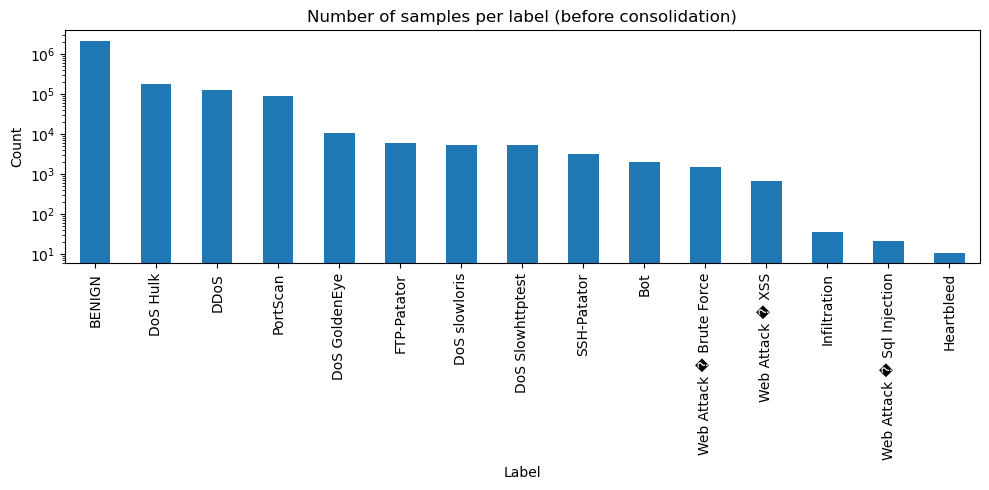

In [15]:
# Visualize the imbalance
plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Number of samples per label (before consolidation)")
plt.ylabel("Count")
plt.xlabel("Label")
plt.yscale("log")  # log scale because BENIGN heavily outnumbers attacks
plt.tight_layout()
plt.show()

## Section 5: Consolidate Labels into Final Classes

CICIDS2017 has many fine-grained labels (for example, DoS Hulk, DoS GoldenEye,
and DoS Slowloris are all separate labels, but for this project they are all
treated as one class: DDoS).

Labels with very few samples (such as Heartbleed or Infiltration) are dropped
entirely, because there is not enough data to train a reliable classifier for
them. This decision is intentional and is explained in the project report.

Final class set used in this project:
- BENIGN
- DDoS
- PortScan
- BruteForce
- Bot


In [16]:
# Mapping from original CICIDS2017 labels to the final consolidated classes
label_mapping = {
    "BENIGN": "BENIGN",

    "DoS Hulk": "DDoS",
    "DoS GoldenEye": "DDoS",
    "DoS slowloris": "DDoS",
    "DoS Slowhttptest": "DDoS",
    "DDoS": "DDoS",

    "PortScan": "PortScan",

    "FTP-Patator": "BruteForce",
    "SSH-Patator": "BruteForce",

    "Bot": "Bot",
}

# Apply the mapping. Labels not in the dictionary become NaN and are dropped
# (this removes rare classes like Heartbleed, Infiltration, Web Attack variants)
df["Label"] = df["Label"].map(label_mapping)

before_rows = df.shape[0]
df.dropna(subset=["Label"], inplace=True)
after_rows = df.shape[0]

print(f"Rows before dropping unused labels: {before_rows}")
print(f"Rows after dropping unused labels:  {after_rows}")

print("\nFinal class distribution:")
print(df["Label"].value_counts())

Rows before dropping unused labels: 2520798
Rows after dropping unused labels:  2518608

Final class distribution:
Label
BENIGN        2095057
DDoS           321759
PortScan        90694
BruteForce       9150
Bot              1948
Name: count, dtype: int64


## Section 6: Feature Selection

Not every column in CICIDS2017 is useful for training. Some columns must be
removed because they would cause the model to "cheat" (data leakage), and
others are simply not useful signals.

Removed columns:
- Flow ID, Source IP, Destination IP, Timestamp
  (these identify a specific connection, not a general pattern - keeping
  them would make the model memorize IP addresses instead of learning
  actual attack behavior)

Kept columns (the features actually used for training):
- Flow duration, packet counts, byte counts, packets/second, bytes/second
- Inter-arrival time statistics (timing between packets)
- TCP flag counts (SYN, ACK, RST, FIN, PSH)
- Packet length statistics (mean, min, max)

These are the same categories of features that the live capture agent will
compute in real time, so the model can be reused directly with live traffic.


In [17]:
# Columns to drop - identifiers that should not be learned as patterns
columns_to_drop = ["Flow ID", "Source IP", "Destination IP", "Timestamp",
                    "Source Port", "Destination Port"]

# Only drop columns that actually exist in this dataset version
columns_to_drop = [c for c in columns_to_drop if c in df.columns]

df.drop(columns=columns_to_drop, inplace=True)

print("Dropped identifier columns:", columns_to_drop)
print("Remaining columns:", df.shape[1])

Dropped identifier columns: ['Destination Port']
Remaining columns: 78


In [18]:
# Selected feature set
# This list mirrors the flow features the live capture agent computes,
# so the model trained here can be used directly on live traffic later.
SELECTED_FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "SYN Flag Count",
    "ACK Flag Count",
    "RST Flag Count",
    "FIN Flag Count",
    "PSH Flag Count",
    "Packet Length Mean",
    "Packet Length Std",
    "Min Packet Length",
    "Max Packet Length",
]

# Only keep features that actually exist in this dataset (column names can
# vary slightly between CICIDS2017 releases)
SELECTED_FEATURES = [f for f in SELECTED_FEATURES if f in df.columns]

print(f"Using {len(SELECTED_FEATURES)} features:")
for f in SELECTED_FEATURES:
    print(" -", f)

Using 20 features:
 - Flow Duration
 - Total Fwd Packets
 - Total Backward Packets
 - Total Length of Fwd Packets
 - Total Length of Bwd Packets
 - Flow Bytes/s
 - Flow Packets/s
 - Flow IAT Mean
 - Flow IAT Std
 - Flow IAT Max
 - Flow IAT Min
 - SYN Flag Count
 - ACK Flag Count
 - RST Flag Count
 - FIN Flag Count
 - PSH Flag Count
 - Packet Length Mean
 - Packet Length Std
 - Min Packet Length
 - Max Packet Length


In [19]:
# Build the final modeling dataframe: selected features + label
model_df = df[SELECTED_FEATURES + ["Label"]].copy()

# Safety check: replace any remaining infinite values that might exist
# only within the selected columns, then drop those rows
model_df.replace([np.inf, -np.inf], np.nan, inplace=True)
model_df.dropna(inplace=True)

print("Final modeling dataset shape:", model_df.shape)
model_df.head()

Final modeling dataset shape: (2518608, 21)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,...,SYN Flag Count,ACK Flag Count,RST Flag Count,FIN Flag Count,PSH Flag Count,Packet Length Mean,Packet Length Std,Min Packet Length,Max Packet Length,Label
0,3,2,0,12,0,4.000000e+06,666666.66670,3.0,0.0,3,...,0,1,0,0,0,6.0,0.0,6,6,BENIGN
1,109,1,1,6,6,1.100917e+05,18348.62385,109.0,0.0,109,...,0,1,0,0,0,6.0,0.0,6,6,BENIGN
2,52,1,1,6,6,2.307692e+05,38461.53846,52.0,0.0,52,...,0,1,0,0,0,6.0,0.0,6,6,BENIGN
3,34,1,1,6,6,3.529412e+05,58823.52941,34.0,0.0,34,...,0,1,0,0,0,6.0,0.0,6,6,BENIGN
4,3,2,0,12,0,4.000000e+06,666666.66670,3.0,0.0,3,...,0,1,0,0,0,6.0,0.0,6,6,BENIGN


### Optional: Check feature correlation

Highly correlated features carry duplicate information. This step is for
inspection only - it does not automatically remove anything, but it helps
justify feature choices in the report.


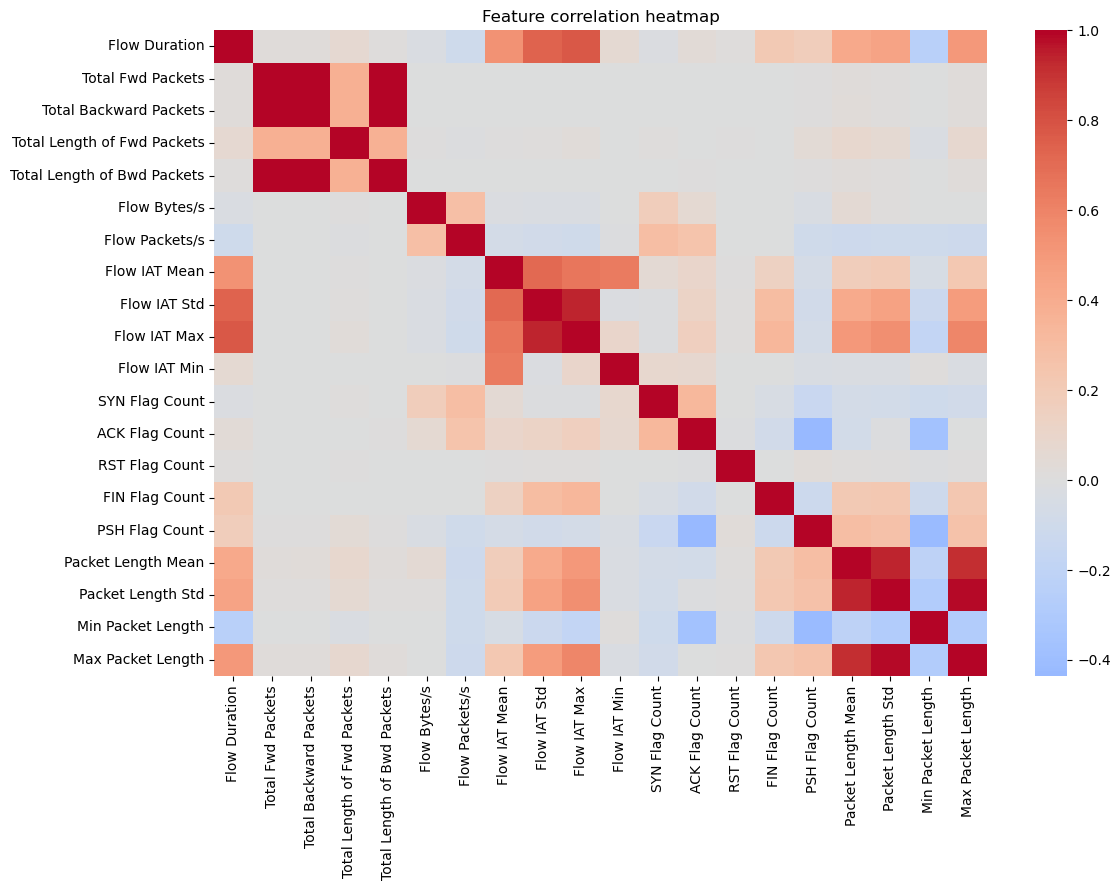

In [20]:
plt.figure(figsize=(12, 9))
correlation_matrix = model_df[SELECTED_FEATURES].corr()
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

## Section 7: Encode the Label Column

Machine learning models work with numbers, not text. This step converts
the text labels (BENIGN, DDoS, PortScan, BruteForce, Bot) into numeric
class values using LabelEncoder.

The mapping is saved, because the backend needs to convert the model's
numeric predictions back into readable attack names.


In [21]:
label_encoder = LabelEncoder()
model_df["Label_Encoded"] = label_encoder.fit_transform(model_df["Label"])

# Show the mapping between text labels and numbers
label_mapping_readable = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
)
print("Label encoding used:")
for text_label, number in label_mapping_readable.items():
    print(f"  {text_label} -> {number}")

Label encoding used:
  BENIGN -> 0
  Bot -> 1
  BruteForce -> 2
  DDoS -> 3
  PortScan -> 4


## Section 8: Split Data into Training and Testing Sets

The data is split into a training set (used to teach the model) and a
testing set (used to check how well the model performs on data it has
never seen).

stratify=y ensures that both the training and testing sets contain the
same proportion of each class - this matters a lot here because some
classes (like Bot) have far fewer samples than others.


In [22]:
X = model_df[SELECTED_FEATURES]
y = model_df["Label_Encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% training, 20% testing
    random_state=42,     # fixed seed so results are reproducible
    stratify=y            # preserve class proportions in both sets
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2014886, 20)
Testing set size: (503722, 20)


## Section 9: Handle Class Imbalance with SMOTE

Because BENIGN traffic vastly outnumbers attack traffic, a model trained
directly on this data would become biased toward predicting BENIGN for
almost everything.

SMOTE (Synthetic Minority Oversampling Technique) fixes this by creating
synthetic examples of the minority classes so all classes have a more
balanced number of samples.

Important: SMOTE is applied only to the training set, never to the test
set. The test set must reflect real-world conditions to give an honest
evaluation of the model.


In [26]:
# Downcast numeric columns to smaller dtypes before SMOTE to reduce memory
# usage. float64 -> float32 and int64 -> int32 halves memory footprint
# with no meaningful loss of precision for this use case.
for col in X_train.select_dtypes(include=["float64"]).columns:
    X_train[col] = X_train[col].astype("float32")

for col in X_train.select_dtypes(include=["int64"]).columns:
    X_train[col] = X_train[col].astype("int32")

print("Class distribution before SMOTE:")
print(y_train.value_counts())

# sampling_strategy="not majority" oversamples only the minority classes,
# instead of blowing every class up to match BENIGN exactly. This keeps
# the resulting dataset much smaller and avoids running out of memory.
smote = SMOTE(
    random_state=42,
    sampling_strategy="not majority",
    k_neighbors=5
)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
print("\nBalanced training set shape:", X_train_balanced.shape)

Class distribution before SMOTE:
Label_Encoded
0    1676045
3     257407
4      72555
2       7320
1       1559
Name: count, dtype: int64

Class distribution after SMOTE:
Label_Encoded
0    1676045
3    1676045
4    1676045
2    1676045
1    1676045
Name: count, dtype: int64

Balanced training set shape: (8380225, 20)


## Section 10: Scale the Features

Features in this dataset have very different ranges (for example, flow
duration might be in the millions, while flag counts are small integers).
Scaling puts all features on a comparable scale.

Tree-based models like Random Forest and XGBoost do not strictly require
this step, but it is included because:
1. It is good practice
2. It keeps the pipeline consistent if a different model type is tried later
3. The exact same scaler must be used later on live traffic data, so it is
   saved here and reused by the backend


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Scaling complete.
Training data shape: (8380225, 20)
Testing data shape: (503722, 20)


## Section 11: Train a Random Forest Model

Random Forest is used as the first, baseline model. It is fast to train,
handles many features well, and is easy to interpret through feature
importance scores.


In [28]:
# n_jobs=2 instead of -1: using every CPU core in parallel means each
# core needs its own memory copy of the training data, which caused the
# MemoryError. Limiting parallelism keeps memory use predictable.
#
# max_samples=0.5: each individual tree trains on a random 50% subsample
# of the data instead of the full balanced dataset. This is standard
# Random Forest behavior (not a shortcut that hurts accuracy) and cuts
# per-tree memory usage substantially on large datasets.
rf_model = RandomForestClassifier(
    n_estimators=100,      # reduced from 150
    max_depth=15,           # reduced from 20
    max_samples=0.5,         # NEW: each tree sees only half the data
    random_state=42,
    n_jobs=2,                # reduced from -1
    verbose=2                  # prints progress per tree as a rough time indicator
)

rf_model.fit(X_train_scaled, y_train_balanced)

print("Random Forest training complete.")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 2 of 100
building tree 1 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100


[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:  4.3min


building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:  9.8min finished


## Section 12: Train an XGBoost Model

XGBoost is a gradient boosting model that often outperforms Random Forest
on structured, tabular data like this. It is trained here so its results
can be compared directly against Random Forest before choosing which one
to actually deploy.


In [29]:
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist",     # required for GPU support
    device="cuda",            # runs on Colab's GPU instead of CPU
    verbosity=1
)

xgb_model.fit(X_train_scaled, y_train_balanced)

print("XGBoost training complete.")

XGBoost training complete.


## Section 13: Evaluate Both Models

Accuracy alone is misleading on imbalanced data (a model that always
predicts BENIGN could still score high accuracy). Instead, this section
looks at:

- Precision: of everything the model flagged as an attack, how much
  was actually an attack
- Recall: of all the real attacks that happened, how many did the model
  actually catch (this is the most important metric for a security
  system - missing a real attack is worse than a false alarm)
- F1-score: a balance between precision and recall
- Confusion matrix: shows exactly which classes get confused with which


In [30]:
def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)

    print(f"===== {model_name} Evaluation =====\n")
    print("Overall Accuracy:", accuracy_score(y_test, predictions))
    print("Weighted F1 Score:", f1_score(y_test, predictions, average="weighted"))
    print()
    print("Detailed classification report:")
    print(classification_report(
        y_test, predictions,
        target_names=label_encoder.classes_
    ))

    return predictions

rf_predictions = evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.6s


===== Random Forest Evaluation =====

Overall Accuracy: 0.9719388869257249
Weighted F1 Score: 0.9828040013807495

Detailed classification report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.97      0.98    419012
         Bot       0.03      0.99      0.06       389
  BruteForce       0.58      0.97      0.72      1830
        DDoS       0.99      1.00      0.99     64352
    PortScan       0.99      1.00      0.99     18139

    accuracy                           0.97    503722
   macro avg       0.72      0.98      0.75    503722
weighted avg       1.00      0.97      0.98    503722



[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.8s finished


In [31]:
xgb_predictions = evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")

===== XGBoost Evaluation =====

Overall Accuracy: 0.9681391720036051
Weighted F1 Score: 0.9798699421238231

Detailed classification report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.96      0.98    419012
         Bot       0.03      0.99      0.07       389
  BruteForce       0.33      0.97      0.49      1830
        DDoS       0.99      0.99      0.99     64352
    PortScan       0.99      1.00      0.99     18139

    accuracy                           0.97    503722
   macro avg       0.67      0.98      0.70    503722
weighted avg       0.99      0.97      0.98    503722



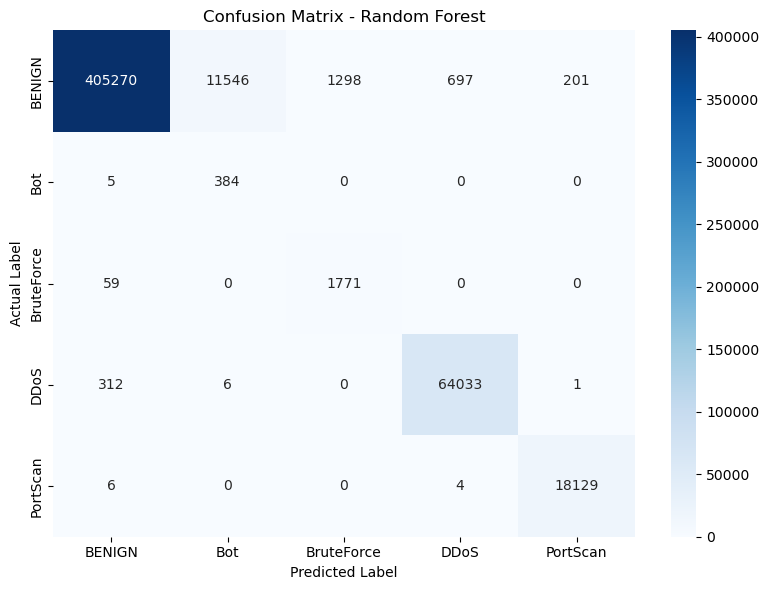

In [32]:
# Confusion matrix for the Random Forest model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

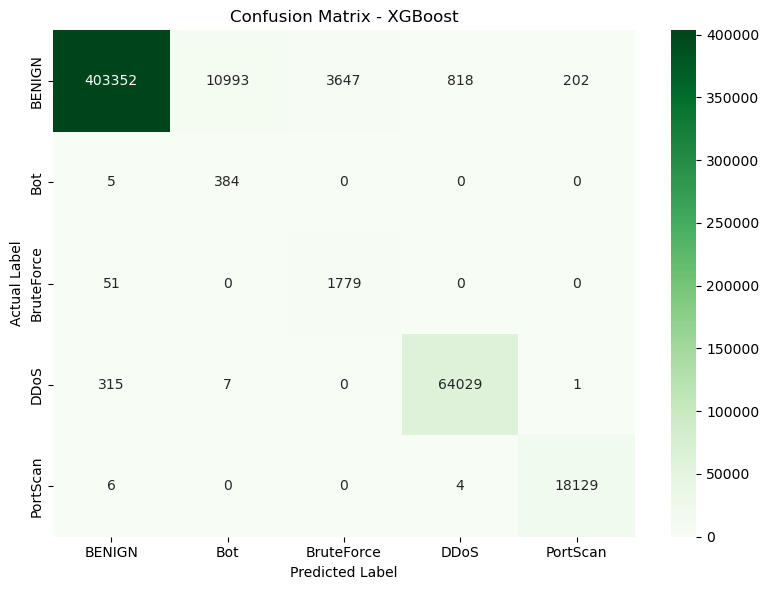

In [33]:
# Confusion matrix for the XGBoost model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, xgb_predictions)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - XGBoost")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

### Choosing the final model

Compare the weighted F1 scores and the confusion matrices printed above.
Whichever model has better recall on the attack classes (not just overall
accuracy) should be selected as the final model.

The code below assumes XGBoost is selected, since it typically performs
better on this type of dataset. If Random Forest scored better in your
run, change `final_model = xgb_model` to `final_model = rf_model` below.


In [34]:
# Select the final model to deploy to the backend
final_model = xgb_model
final_model_name = "XGBoost"

print(f"Selected final model: {final_model_name}")

Selected final model: XGBoost


## Section 14: Feature Importance

This shows which features the model relied on most when making decisions.
This is useful both for the project report and as a sanity check
(for example, SYN flag count and packets/second should matter a lot for
detecting DDoS and port scans - if they don't, something may be wrong).


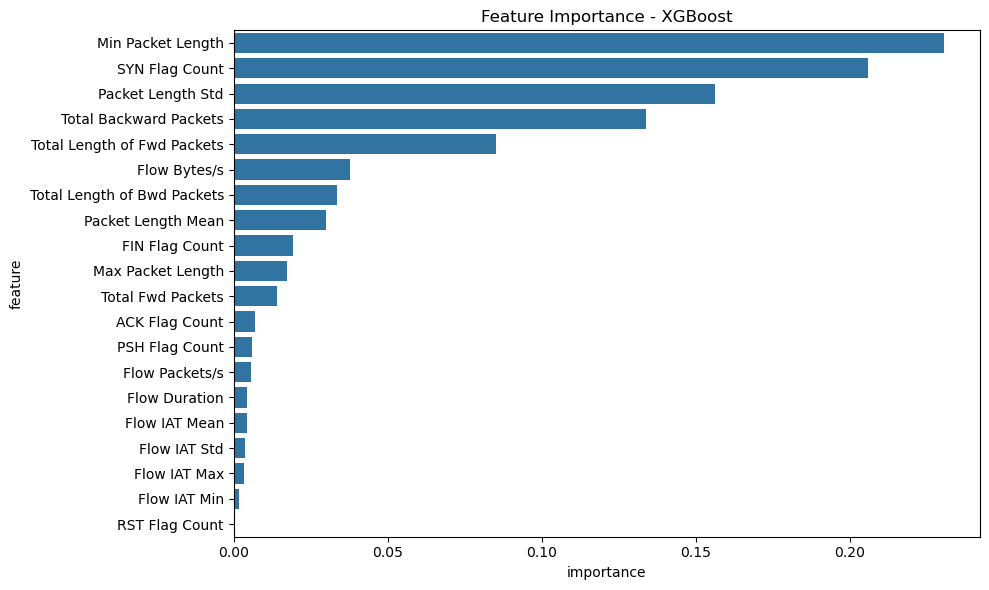

,feature,importance
18,Min Packet Length,0.230626
11,SYN Flag Count,0.205831
17,Packet Length Std,0.156242
2,Total Backward Packets,0.133860
3,Total Length of Fwd Packets,0.085144
5,Flow Bytes/s,0.037708
4,Total Length of Bwd Packets,0.033546
16,Packet Length Mean,0.030016
14,FIN Flag Count,0.019250
19,Max Packet Length,0.017345


In [35]:
importances = final_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="importance", y="feature")
plt.title(f"Feature Importance - {final_model_name}")
plt.tight_layout()
plt.show()

feature_importance_df

## Section 15: Model Explainability with SHAP

SHAP (SHapley Additive exPlanations) explains individual predictions -
not just which features matter overall, but why the model made a specific
decision for a specific row of traffic.

This is what powers the AI Copilot's ability to say things like:
"This was flagged mainly due to high SYN count and low flow duration."

Note: SHAP can be slow on large datasets, so a sample of the test set is
used here instead of the full test set.


In [36]:
# Use a small sample for SHAP to keep computation fast
sample_size = min(200, X_test_scaled.shape[0])
X_sample = X_test_scaled[:sample_size]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed for", sample_size, "samples")

SHAP values computed for 200 samples


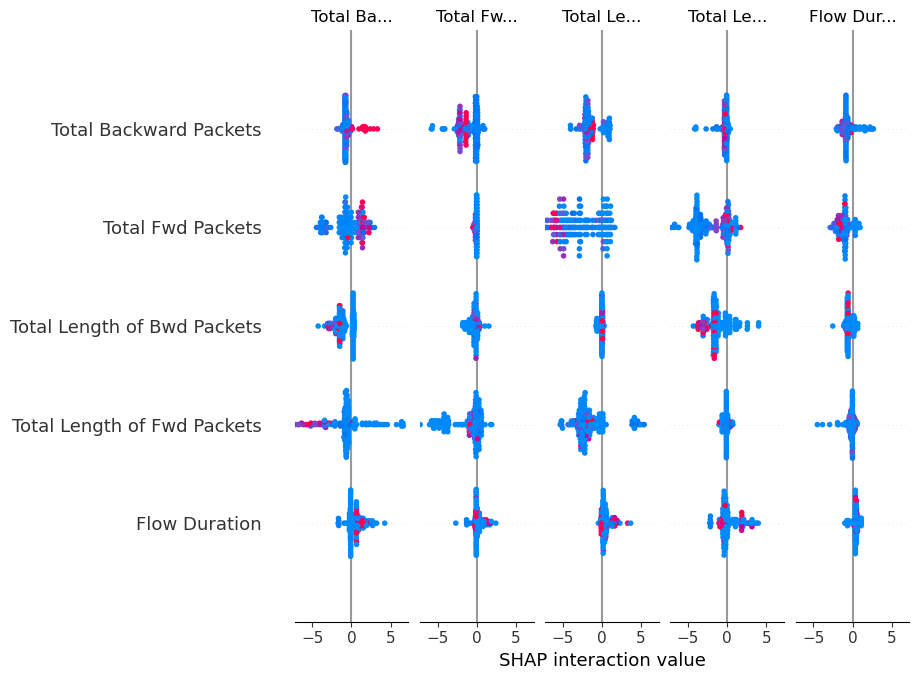

In [37]:
# Summary plot: shows which features matter most across many predictions,
# and whether high or low values push toward an attack classification
shap.summary_plot(
    shap_values, X_sample,
    feature_names=SELECTED_FEATURES,
    show=True
)

In [38]:
# Example: explain one single prediction in detail
# This is the same kind of explanation the AI Copilot will generate in
# plain English for the analyst
sample_index = 0
predicted_class_index = final_model.predict(X_sample[sample_index:sample_index+1])[0]
predicted_class_name = label_encoder.inverse_transform([predicted_class_index])[0]

print(f"Explaining prediction for sample #{sample_index}")
print(f"Predicted class: {predicted_class_name}")
print()
print("Feature values for this sample:")
for feature_name, value in zip(SELECTED_FEATURES, X_sample[sample_index]):
    print(f"  {feature_name}: {value:.4f}")

Explaining prediction for sample #0
Predicted class: BENIGN

Feature values for this sample:
  Flow Duration: 0.2948
  Total Fwd Packets: -0.0111
  Total Backward Packets: -0.0108
  Total Length of Fwd Packets: -0.0834
  Total Length of Bwd Packets: -0.0049
  Flow Bytes/s: -0.0351
  Flow Packets/s: -0.2530
  Flow IAT Mean: 1.6420
  Flow IAT Std: 1.1527
  Flow IAT Max: 0.4174
  Flow IAT Min: -0.0148
  SYN Flag Count: -0.2429
  ACK Flag Count: -0.6159
  RST Flag Count: -0.0082
  FIN Flag Count: -0.1597
  PSH Flag Count: -1.1871
  Packet Length Mean: -0.3048
  Packet Length Std: -0.4256
  Min Packet Length: 2.4837
  Max Packet Length: -0.4275


## Section 16: Save the Trained Model

This step saves three files that the FastAPI backend needs:

1. `model.pkl` - the trained classifier itself
2. `scaler.pkl` - the same StandardScaler used during training, needed to
   scale live traffic features the exact same way
3. `feature_list.json` - the exact list and order of features the model
   expects, so live features are always passed in the correct order
4. `label_mapping.json` - maps the model's numeric output back into
   readable attack names for the dashboard

All files are saved into an `output/` folder. Copy these files into the
backend's `backend/ml/` folder before running the backend.


In [39]:
OUTPUT_FOLDER = "output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Save the trained model
joblib.dump(final_model, os.path.join(OUTPUT_FOLDER, "model.pkl"))

# Save the scaler
joblib.dump(scaler, os.path.join(OUTPUT_FOLDER, "scaler.pkl"))

# Save the feature list and order
with open(os.path.join(OUTPUT_FOLDER, "feature_list.json"), "w") as f:
    json.dump(SELECTED_FEATURES, f, indent=2)

# Save the label mapping (number -> attack name)
label_mapping_output = {
    str(number): text_label
    for text_label, number in label_mapping_readable.items()
}
with open(os.path.join(OUTPUT_FOLDER, "label_mapping.json"), "w") as f:
    json.dump(label_mapping_output, f, indent=2)

print("Saved files:")
print(" -", os.path.join(OUTPUT_FOLDER, "model.pkl"))
print(" -", os.path.join(OUTPUT_FOLDER, "scaler.pkl"))
print(" -", os.path.join(OUTPUT_FOLDER, "feature_list.json"))
print(" -", os.path.join(OUTPUT_FOLDER, "label_mapping.json"))

Saved files:
 - output\model.pkl
 - output\scaler.pkl
 - output\feature_list.json
 - output\label_mapping.json


## Section 17: Sanity Check - Reload and Test the Saved Model

Before moving on, this section reloads the saved files exactly the way the
backend will, and runs one test prediction. This confirms the saved files
actually work correctly together.


In [40]:
# Reload everything fresh, simulating what the backend does at startup
loaded_model = joblib.load(os.path.join(OUTPUT_FOLDER, "model.pkl"))
loaded_scaler = joblib.load(os.path.join(OUTPUT_FOLDER, "scaler.pkl"))

with open(os.path.join(OUTPUT_FOLDER, "feature_list.json")) as f:
    loaded_features = json.load(f)

with open(os.path.join(OUTPUT_FOLDER, "label_mapping.json")) as f:
    loaded_label_mapping = json.load(f)

# Take one real row from the test set to simulate an incoming live flow
test_row = X_test.iloc[[0]][loaded_features]

# Scale it using the saved scaler
test_row_scaled = loaded_scaler.transform(test_row)

# Predict
prediction_number = loaded_model.predict(test_row_scaled)[0]
prediction_confidence = loaded_model.predict_proba(test_row_scaled).max()
prediction_label = loaded_label_mapping[str(prediction_number)]

print("Sanity check result:")
print("Predicted class:", prediction_label)
print("Confidence:", round(float(prediction_confidence), 4))
print()
print("If this printed a sensible label and a confidence value, the saved")
print("model, scaler, and feature list are all working together correctly")
print("and are ready to be copied into the backend's ml/ folder.")

Sanity check result:
Predicted class: BENIGN
Confidence: 1.0

If this printed a sensible label and a confidence value, the saved
model, scaler, and feature list are all working together correctly
and are ready to be copied into the backend's ml/ folder.


### Passed random individual rows from that 20% test set

you'd get different confidence values for each — some rows might be obviously BENIGN (confidence near 1.0, like Section 17 result), others might be genuinely ambiguous edge cases (confidence closer to 0.5-0.6, where the model is less sure).

**NOTE** : Section 17 only checks exactly one row: the very first row (index 0) of your 20% test set. It doesn't touch or check any of the other rows in that test set at all.


In [49]:
import random

# Pick a few random rows from the test set and check their individual predictions
sample_indices = random.sample(range(len(X_test)), 5)

for idx in sample_indices:
    row = X_test.iloc[[idx]][loaded_features]
    row_scaled = loaded_scaler.transform(row)

    pred_number = loaded_model.predict(row_scaled)[0]
    pred_confidence = loaded_model.predict_proba(row_scaled).max()
    pred_label = loaded_label_mapping[str(pred_number)]

    actual_label_number = y_test.iloc[idx]
    actual_label = label_encoder.inverse_transform([actual_label_number])[0]

    print(f"Row {idx}: predicted={pred_label} (confidence={pred_confidence:.4f}), actual={actual_label}")

Row 249087: predicted=BENIGN (confidence=0.9998), actual=BENIGN
Row 118716: predicted=BENIGN (confidence=1.0000), actual=BENIGN
Row 315712: predicted=BENIGN (confidence=0.9992), actual=BENIGN
Row 451705: predicted=BENIGN (confidence=0.9957), actual=BENIGN
Row 301973: predicted=BENIGN (confidence=1.0000), actual=BENIGN


## Next Steps

1. Copy `output/model.pkl`, `output/scaler.pkl`, and `output/feature_list.json`
   into `backend/ml/` so the FastAPI backend can load them
2. Keep `output/label_mapping.json` for reference - the backend's label
   encoding should match the class names used here (BENIGN, DDoS, PortScan,
   BruteForce, Bot)
3. Restart the backend so it loads the newly trained model
4. Test the full pipeline using either the live capture agent or the
   dataset replay script
